In [1]:
import pandas as pd

data_path = r"C:\Users\Admin\data\train_processed_advanced.csv"
df = pd.read_csv(data_path)

print(df.shape)

(336715, 54)


In [2]:
X = df.drop("attack_class", axis=1)
y = df["attack_class"]

print("X:", X.shape)
print("y:", y.shape)

X: (336715, 53)
y: (336715,)


In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaling done")
print("X_scaled shape:", X_scaled.shape)

Scaling done
X_scaled shape: (336715, 53)


Dataset Loaded: (336715, 54)
Features shape: (336715, 53)
Target shape: (336715,)
Target Encoding Done
Scaling Done: (336715, 53)
Train/Test Split Done
Model Training Completed
Prediction Completed

===== MODEL PERFORMANCE =====
Accuracy : 0.99977725970034
Precision: 0.9997772443360531
Recall   : 0.99977725970034
F1 Score : 0.9997772415606944

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     13340
           1       1.00      1.00      1.00     13499
           2       1.00      1.00      1.00     13629
           3       1.00      1.00      1.00     13368
           4       1.00      1.00      1.00     13507

    accuracy                           1.00     67343
   macro avg       1.00      1.00      1.00     67343
weighted avg       1.00      1.00      1.00     67343



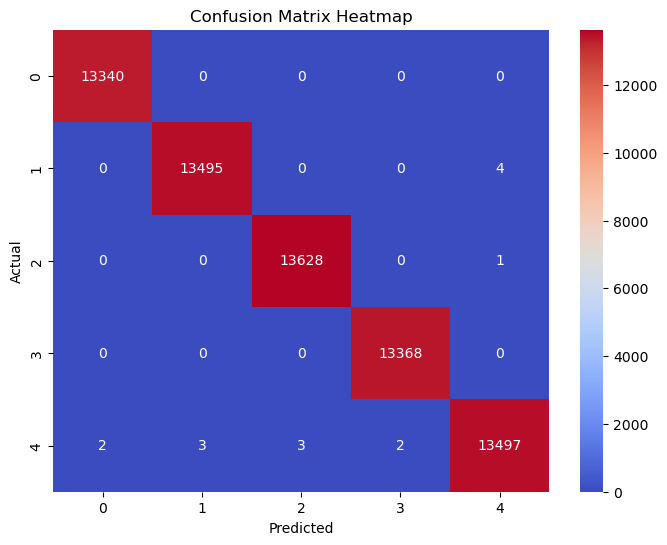

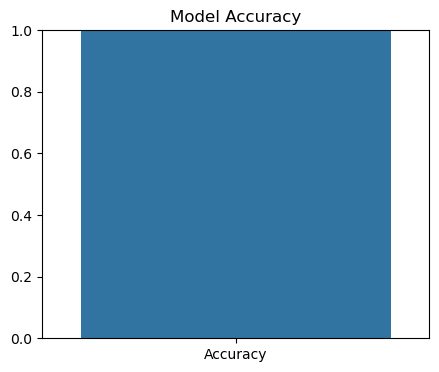

In [5]:
# ==============================
# 1. IMPORT LIBRARIES
# ==============================
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

import seaborn as sns
import matplotlib.pyplot as plt

# ==============================
# 2. LOAD DATASET
# ==============================
data_path = r"C:\Users\Admin\data\train_processed_advanced.csv"

df = pd.read_csv(data_path)

print("Dataset Loaded:", df.shape)

# ==============================
# 3. CREATE FEATURES & TARGET
# ==============================
X = df.drop("attack_class", axis=1)
y = df["attack_class"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

# ==============================
# 4. HANDLE MISSING VALUES
# ==============================
X = X.fillna(0)

# ==============================
# 5. ENCODE TARGET VARIABLE
# ==============================
le = LabelEncoder()
y = le.fit_transform(y)

print("Target Encoding Done")

# ==============================
# 6. FEATURE SCALING
# ==============================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaling Done:", X_scaled.shape)

# ==============================
# 7. TRAIN-TEST SPLIT
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("Train/Test Split Done")

# ==============================
# 8. TRAIN MODEL (RANDOM FOREST)
# ==============================
model = RandomForestClassifier(n_estimators=100, random_state=42)

model.fit(X_train, y_train)

print("Model Training Completed")

# ==============================
# 9. PREDICTION
# ==============================
y_pred = model.predict(X_test)

print("Prediction Completed")

# ==============================
# 10. MODEL EVALUATION
# ==============================
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("\n===== MODEL PERFORMANCE =====")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# ==============================
# 11. CONFUSION MATRIX
# ==============================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="coolwarm")

plt.title("Confusion Matrix Heatmap")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# ==============================
# 12. ACCURACY GRAPH
# ==============================
plt.figure(figsize=(5,4))
sns.barplot(x=["Accuracy"], y=[accuracy])
plt.ylim(0,1)

plt.title("Model Accuracy")

plt.show()